In [1]:
#Tabela de Voos importadas manualmente(Upload)

#importação de bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
%matplotlib inline

In [3]:
#1 e 2
#Ler arquivo CSV
df = pd.read_csv('atividade3 - Dataset_sint_tico_de_voos (1).csv')
df.head()

,FL_DATE,OP_UNIQUE_CARRIER,TAIL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY,ARR_DELAY,DISTANCE
0,2023-01-01,AZUL,N1000,GIG,FOR,1369,7.0,32.0,4984
1,2023-01-02,SW,N1001,BSB,MIA,1986,-42.0,-38.0,4200
2,2023-01-03,LATAM,N1002,ORD,REC,1534,-30.0,21.0,1833
3,2023-01-04,AZUL,N1003,JFK,FOR,146,-39.0,52.0,2352
4,2023-01-05,UA,N1004,GIG,SFO,1734,-24.0,42.0,710


In [4]:
df.shape

(100, 9)

In [5]:
df.describe()

,CRS_DEP_TIME,DEP_DELAY,ARR_DELAY,DISTANCE
count,100.00000,90.000000,90.000000,100.000000
mean,1242.93000,9.066667,7.688889,2897.620000
std,686.19325,33.684525,39.095574,1420.354052
min,16.00000,-57.000000,-103.000000,337.000000
25%,626.00000,-15.000000,-20.500000,1859.250000
50%,1230.50000,7.000000,6.000000,2940.000000
75%,1812.25000,33.250000,36.250000,4266.000000
max,2331.00000,106.000000,90.000000,4984.000000


In [6]:
#3
#Verifica tipos de dados de cada coluna.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            100 non-null    object 
 1   OP_UNIQUE_CARRIER  100 non-null    object 
 2   TAIL_NUM           100 non-null    object 
 3   ORIGIN             100 non-null    object 
 4   DEST               100 non-null    object 
 5   CRS_DEP_TIME       100 non-null    int64  
 6   DEP_DELAY          90 non-null     float64
 7   ARR_DELAY          90 non-null     float64
 8   DISTANCE           100 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 7.2+ KB


In [7]:
#4
#Verificando Nulos por Coluna
total_nulos = df.isnull().sum()
print(total_nulos)

FL_DATE               0
OP_UNIQUE_CARRIER     0
TAIL_NUM              0
ORIGIN                0
DEST                  0
CRS_DEP_TIME          0
DEP_DELAY            10
ARR_DELAY            10
DISTANCE              0
dtype: int64


In [8]:
#Criando cópia para testes
df_imputado = df.copy()

In [9]:
#Imputando valores
df_imputado["DEP_DELAY"] = df_imputado["DEP_DELAY"].fillna(df["DEP_DELAY"].median())
df_imputado["ARR_DELAY"] = df_imputado["ARR_DELAY"].fillna(df["ARR_DELAY"].median())

print(df_imputado.isnull().sum())


FL_DATE              0
OP_UNIQUE_CARRIER    0
TAIL_NUM             0
ORIGIN               0
DEST                 0
CRS_DEP_TIME         0
DEP_DELAY            0
ARR_DELAY            0
DISTANCE             0
dtype: int64


Como o padrão de datas já está no ISO 8601, não vou alterar as datas.

Da mesma forma espaços ou erros de formatação ou texto.

In [10]:
#6
#Criação de Colunas
df_imputado["ATRASO_PARTIDA_MAIOR_15MIN"] = df_imputado["DEP_DELAY"]>15
df_imputado["ATRASO_CHEGADA_MAIOR_15MIN"] = df_imputado["ARR_DELAY"]>15

df_imputado["VOO_MAIORQ_2KM"] = df_imputado["DISTANCE"]>2000
df_imputado["VOO_MENORQ_2km"] = df_imputado["DISTANCE"]<=2000


df_imputado.head()

,FL_DATE,OP_UNIQUE_CARRIER,TAIL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY,ARR_DELAY,DISTANCE,ATRASO_PARTIDA_MAIOR_15MIN,ATRASO_CHEGADA_MAIOR_15MIN,VOO_MAIORQ_2KM,VOO_MENORQ_2km
0,2023-01-01,AZUL,N1000,GIG,FOR,1369,7.0,32.0,4984,False,True,True,False
1,2023-01-02,SW,N1001,BSB,MIA,1986,-42.0,-38.0,4200,False,False,True,False
2,2023-01-03,LATAM,N1002,ORD,REC,1534,-30.0,21.0,1833,False,True,False,True
3,2023-01-04,AZUL,N1003,JFK,FOR,146,-39.0,52.0,2352,False,True,True,False
4,2023-01-05,UA,N1004,GIG,SFO,1734,-24.0,42.0,710,False,True,False,True


In [11]:
partida_atrasada_true = df_imputado["ATRASO_PARTIDA_MAIOR_15MIN"].mean() * 100
partida_atrasada_false = 100 - partida_atrasada_true

print(f'Percental de Voos com atrasos maiores que 15 minutos na partida: {partida_atrasada_true}%')
print(f'Percental de Voos sem atrasos maiores que 15 minutos na partida: {partida_atrasada_false}%')




Percental de Voos com atrasos maiores que 15 minutos na partida: 38.0%
Percental de Voos sem atrasos maiores que 15 minutos na partida: 62.0%


In [12]:
#Voos longos a partir de 2000km e curtos menor ou igual que 2000km
atrasos_partida_voos_longos = (df_imputado["ATRASO_PARTIDA_MAIOR_15MIN"] & df_imputado["VOO_MAIORQ_2KM"]).mean() * 100
atrasos_partida_voos_curtos = (df_imputado["ATRASO_PARTIDA_MAIOR_15MIN"] & df_imputado["VOO_MENORQ_2km"]).mean() * 100
atrasos_chegada_voos_longos = (df_imputado["ATRASO_CHEGADA_MAIOR_15MIN"] & df_imputado["VOO_MAIORQ_2KM"]).mean() * 100
atrasos_chegada_voos_curtos = (df_imputado["ATRASO_CHEGADA_MAIOR_15MIN"] & df_imputado["VOO_MENORQ_2km"]).mean() * 100

print(f'Percentual de atrasos na partida de voos longos: {atrasos_partida_voos_longos:.2f}% ')
print(f'Percentual de atrasos na partida de voos curtos: {atrasos_partida_voos_curtos}% ')
print(f'Percentual de atrasos na chegada de voos longos: {atrasos_chegada_voos_longos}% ')
print(f'Percentual de atrasos na chegada de voos curtos: {atrasos_chegada_voos_curtos}% ')



Percentual de atrasos na partida de voos longos: 28.00% 
Percentual de atrasos na partida de voos curtos: 10.0% 
Percentual de atrasos na chegada de voos longos: 27.0% 
Percentual de atrasos na chegada de voos curtos: 11.0% 


Podemos identificar que o maior percentual de atraso está atrelado aos voos mais longos.

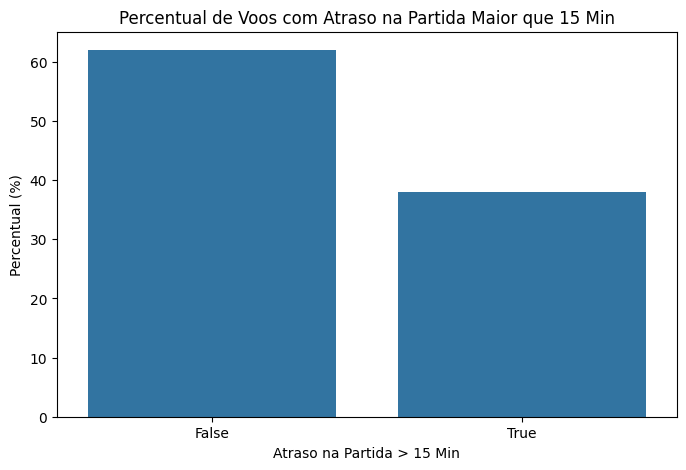

In [13]:
#Gráfico de Partidas atrasadas
percentage_atraso = df_imputado["ATRASO_PARTIDA_MAIOR_15MIN"].value_counts(normalize=True) * 100

df_bar = percentage_atraso.reset_index()
df_bar.columns = ["Atraso Maior Que 15 Min", "Percentual"]

plt.figure(figsize=(8, 5))
sns.barplot(data=df_bar, x="Atraso Maior Que 15 Min", y="Percentual")

plt.ylabel("Percentual (%)")
plt.xlabel("Atraso na Partida > 15 Min")
plt.title("Percentual de Voos com Atraso na Partida Maior que 15 Min")

plt.show()

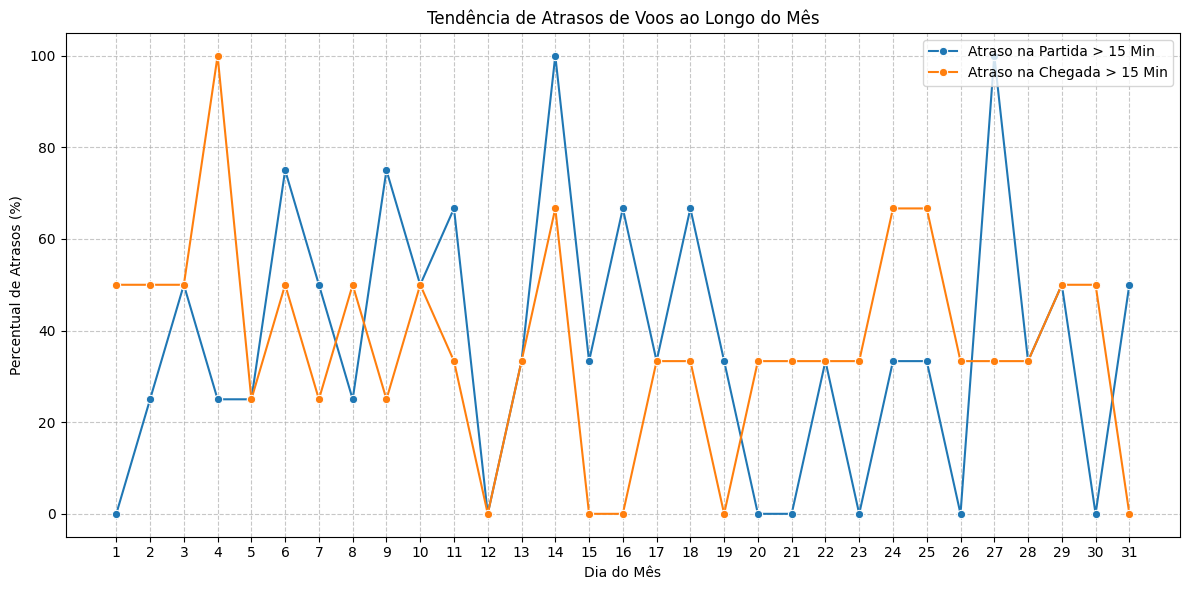

In [14]:
#Atrasos de Chegada e Partida ao Longo do mês
df_imputado['FL_DATE'] = pd.to_datetime(df_imputado['FL_DATE'])
df_imputado['DAY_OF_MONTH'] = df_imputado['FL_DATE'].dt.day

daily_delays = df_imputado.groupby('DAY_OF_MONTH').agg(
    atraso_partida=('ATRASO_PARTIDA_MAIOR_15MIN', lambda x: (x).mean() * 100),
    atraso_chegada=('ATRASO_CHEGADA_MAIOR_15MIN', lambda x: (x).mean() * 100)
).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_delays, x='DAY_OF_MONTH', y='atraso_partida', label='Atraso na Partida > 15 Min', marker='o')
sns.lineplot(data=daily_delays, x='DAY_OF_MONTH', y='atraso_chegada', label='Atraso na Chegada > 15 Min', marker='o')

plt.title('Tendência de Atrasos de Voos ao Longo do Mês')
plt.xlabel('Dia do Mês')
plt.ylabel('Percentual de Atrasos (%)')
plt.xticks(daily_delays['DAY_OF_MONTH'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

A planilha CSV da Atividade 2 e 3 são iguais, portanto fiz a análise parecida mas atualizando o arquivo.